# RhizoVision Explorer — statistical validation reproduction

Reproduction of the statistical validation from: Seethepalli, A., Dhakal, K., Griffiths, M., Guo, H., Freschet, G. T., York, L. M. (2021). *RhizoVision Explorer: open-source software for root image analysis and measurement standardization.* **AoB PLANTS** 13(6):plab056, [doi:10.1093/aobpla/plab056](https://doi.org/10.1093/aobpla/plab056) ([PMC8598384](https://pmc.ncbi.nlm.nih.gov/articles/PMC8598384/)).

**Scope.** The paper validates the RhizoVision Explorer (RVE) image-analysis GUI against ground truth. Regenerating RVE's raw image measurements would require the Windows GUI binary (Zenodo 3747697); instead, this notebook reproduces the paper's **statistical validation exactly as released by the authors**: the R analysis script and all of its input tables (RVE measurements, copper-wire ground truth, WinRhizo/IJ_Rhizo comparisons) are bundled in the authors' Zenodo record [10.5281/zenodo.4677553](https://doi.org/10.5281/zenodo.4677553), which per its own description "should run and produce all graphical output and statistics". The script was written for RStudio and has four small released-version defects (documented in section 4); we apply minimal, printed patches. One input table (`Inputs/all_D.Rdata`) is absent from the deposit, so we reconstruct it from the authors' cited ground-truth dataset using the exact recipe published in the referenced Rose & Lobet (2019) script (section 5).

**日本語:** このノートブックは RhizoVision Explorer 論文の**統計的検証**を、著者公開の R スクリプトと入力データ(Zenodo 4677553)をそのまま実行して再現します。画像計測本体(GUI)の再実行は対象外です。実行には数十分かかることがあります(パッケージのビルド含む)。

**Runtime: CPU only.** No GPU is used; plain R statistics and plotting.

## 1. Install R

**Purpose / expected result:** install the R runtime and system libraries needed to compile R's plotting and data packages (Cairo, PNG/TIFF, XML, curl). This takes a few minutes on a fresh Colab VM.

**日本語:** Colab VM に R 本体と、CRAN パッケージのビルドに必要なシステムライブラリをインストールします(数分)。

In [ ]:
import subprocess

cmds = [
    ["apt-get", "update", "-qq"],
    ["apt-get", "install", "-y", "-qq", "r-base", "r-base-dev",
     "libcurl4-openssl-dev", "libssl-dev", "libxml2-dev",
     "libfontconfig1-dev", "libfreetype6-dev", "libharfbuzz-dev",
     "libfribidi-dev", "libpng-dev", "libtiff5-dev", "libjpeg-dev"],
]
for c in cmds:
    r = subprocess.run(c, capture_output=True, text=True)
    assert r.returncode == 0, (c, r.stderr[-800:])
r = subprocess.run(["R", "--version"], capture_output=True, text=True)
print(r.stdout.splitlines()[0])

R version 4.6.1 (2026-06-24) -- "Happy Hop"


## 2. Download and verify the authors' Zenodo deposit

**Purpose / expected result:** fetch the record metadata from the public Zenodo API, then download `RhizoVisionData_and_stats.zip` (the paper's data + statistical code) and `A_wire_validation.png` from the pinned record **4677553**. The zip's MD5 is asserted against the checksum published in the record (`47f45feba384b8e5510f01238e41419e`), then the archive is extracted under `/content/rve`.

**日本語:** Zenodo の公開 API から pinned record 4677553 のファイルを取得し、レコードに公開されている MD5 チェックサムと照合してから展開します。

In [ ]:
import json, subprocess, hashlib, os

REC = "https://zenodo.org/api/records/4677553"
os.makedirs("/content/rve", exist_ok=True)

r = subprocess.run(["curl", "-sL", "--fail-with-body", REC, "-o", "/content/rve/record.json"],
                   capture_output=True, text=True)
assert r.returncode == 0, r.stderr
record = json.load(open("/content/rve/record.json"))
print("Record title:", record["metadata"]["title"])
print("Record DOI:", record["doi"])

for f in record["files"]:
    dest = os.path.join("/content/rve", f["key"])
    subprocess.run(["curl", "-sL", "--fail-with-body", f["links"]["self"], "-o", dest], check=True)
    md5 = hashlib.md5(open(dest, "rb").read()).hexdigest()
    print(f"{f['key']}: {f['size']} bytes, md5 {md5}")
    assert md5 == f["checksum"].split(":")[1], f"checksum mismatch for {f['key']}"

subprocess.run(["unzip", "-oq", "/content/rve/RhizoVisionData_and_stats.zip", "-d", "/content/rve"], check=True)
for root, _, files in os.walk("/content/rve"):
    for fn in sorted(files):
        p = os.path.join(root, fn)
        print(f"{os.path.relpath(p, '/content/rve'):55s} {os.path.getsize(p):>9d} B")

Record title: Data and statistical code for the manuscript on RhizoVision Explorer for root image analysis
Record DOI: 10.5281/zenodo.4677553


RhizoVisionData_and_stats.zip: 2051208 bytes, md5 47f45feba384b8e5510f01238e41419e


A_wire_validation.png: 271809 bytes, md5 6fedf632bbc513ffd6400cb21e5ca7ea
A_wire_validation.png                                      271809 B
RhizoVisionDataAnalysis.R                                   48022 B
RhizoVisionData_and_stats.zip                             2051208 B
record.json                                                  6932 B
Inputs/IJ_Kimura.csv                                         3488 B
Inputs/McCormackTreesWinRhizo.xlsx                          54368 B
Inputs/all_analyses_WR_IJ_RoseLobet2019.xlsx              1179973 B
Inputs/featuresFreschet.csv                                 55708 B
Inputs/featuresMaize.csv                                    20521 B
Inputs/featuresSimRootsRveDpi1200.csv                       18554 B
Inputs/featuresSimRootsRveDpi800.csv                        17976 B
Inputs/featuresTrees.csv                                    11534 B
Inputs/featuresWheatTcap.csv                                18684 B
Inputs/freschetRootsAnalyseAuto.xlsx      

## 3. Inspect the released analysis script

**Purpose / expected result:** show the script's own package list and input files. The authors' script (`RhizoVisionDataAnalysis.R`) declares `requiredPackages` and loads every table from the `Inputs/` directory with relative paths, exactly as described on the Zenodo record. We display its header so the learner sees the authors' provenance before running it.

**日本語:** 著者のスクリプト冒頭と依存パッケージ宣言を表示し、出所を学習者に見せます。

In [ ]:
script = "/content/rve/RhizoVisionDataAnalysis.R"
src = open(script).read()
print(src[:1600])

preamble <- ("
Title: RhizoVision Explorer: Open-source root image anlaysis for standardizing root measurements
Authors: Seethepalli A, Dhakal K, Griffiths M, Guo H, Freschet G, York LM
Date: April 9, 2021

Validation of RhizoVision Explorer using Copper wires and Compare against WinRhizo


####  #     #             #     ##        #                    
#   # #                    #   #                               
#   # ####  #  ####  ###   #   # #   #### #   ###  ####        
####  #   # #    #  #   #   # #  #  #     #  #   # #   #       
#  #  #   # #   #   #   #   # #  #   ###  #  #   # #   #       
#  #  #   # #  #    #   #    #   #      # #  #   # #   #       
#   # #   # #  ####  ###     #   #  ####  #   ###  #   #       
                                                               
                                                               
#####             #                     
#                 #                     
#     #   # ####  #   ###  ###  ###  ###
#####  # 

## 4. Apply four minimal, printed patches to the released script

**Purpose / expected result:** the released script has four small defects for a headless, current-R run. We copy the script and apply: (1) the RStudio-only working-directory line replaced with `/content/rve`; (2) `IJ_Kimura.csv` read with the `Inputs/` prefix used by every other input; (3) a commented-out column-drop line that breaks the subsequent `rbind` with a 12-column table (10 vs 12 columns); (4) `all()` around a vectorized `if` condition that is an error in R >= 4.2. The full diff is printed; everything else is byte-identical to the release.

**日本語:** 公開スクリプトの4点(作業ディレクトリ、入力パス、列削除によるrbind破綻、ベクトル条件)のみ最小限修正し、差分を表示します。他は原著のままです。

In [ ]:
import re, difflib

src = open(script).read()
src = src.replace(
    "setwd(dirname(rstudioapi::getSourceEditorContext()$path))",
    'setwd("/content/rve")  # COLAB FIX: headless working dir')
src = src.replace(
    'read.csv("IJ_Kimura.csv")',
    'read.csv("./Inputs/IJ_Kimura.csv")  # COLAB FIX: Inputs/ prefix')
src = src.replace(
    "longformatdf <- longformatdf %>% select(-c(SurfArea.cm2.,TotalSurfaceAreaLMY))",
    "# COLAB FIX: released line dropped 2 columns and broke the rbind with dfIjRhizoComplete\n"
    "# longformatdf <- longformatdf %>% select(-c(SurfArea.cm2.,TotalSurfaceAreaLMY))")
src = src.replace(
    "if (colnames(bothThresholds) == colnames(dftoGraph)) {",
    "if (all(colnames(bothThresholds) == colnames(dftoGraph))) {  # COLAB FIX: vector condition")
patched_path = "/content/rve/RhizoVisionDataAnalysis_colab.R"
open(patched_path, "w").write(src)
for line in difflib.unified_diff(open(script).read().splitlines(), src.splitlines(), lineterm="", n=0):
    if line.startswith(("---", "+++", "@@")) or "COLAB FIX" in line:
        print(line)

--- 
+++ 
@@ -77 +77 @@
+setwd("/content/rve")  # COLAB FIX: headless working dir
@@ -209 +209 @@
+dfIjRhizo <- read.csv("./Inputs/IJ_Kimura.csv")  # COLAB FIX: Inputs/ prefix
@@ -290 +290,2 @@
+# COLAB FIX: released line dropped 2 columns and broke the rbind with dfIjRhizoComplete
@@ -298 +299 @@
+if (all(colnames(bothThresholds) == colnames(dftoGraph))) {  # COLAB FIX: vector condition


## 5. Reconstruct the missing ground-truth table `Inputs/all_D.Rdata`

**Purpose / expected result:** the released script loads `Inputs/all_D.Rdata` (`all_D0`: simulated-root ground truth with columns `File.Name, dpi, Sum_length, diam, sufa, vol`), but that file is absent from Zenodo 4677553 and from every other author record (checked 3747697, 4677546, 4677545, 4677751, 4677750). The paper's ground truth is the RSML-derived simulated-root dataset of Rose & Lobet (2019), Zenodo [1159846](https://doi.org/10.5281/zenodo.1159846) (`all_root_data_2D.csv`, per-root segments). We reconstruct `all_D0` with the aggregation recipe published verbatim in the authors' own released script (`Script_upload_1200_fixed.R`, record 1159846): length-weighted mean diameter, summed length/surface/volume per image; ground truth is resolution-independent (RSML units are mm), so each image appears once per DPI with the DPI-prefixed file name the released script expects. File checksums are verified against the record, and the reconstruction is cross-checked against RVE's own 1200-dpi output (expected: close but not identical, since RVE is the method under test).

**日本語:** 公開デポジットに含まれない `all_D.Rdata` を、引用元の Rose & Lobet (2019) データセット(Zenodo 1159846)とその公開レシピから再構成します。単位・DPI 非依存性は RVE の 1200 dpi 出力との比較で検証します。

In [ ]:
import json, subprocess, hashlib

ROSE_REC = "https://zenodo.org/api/records/1159846"
r = subprocess.run(["curl", "-sL", "--fail-with-body", ROSE_REC], capture_output=True, text=True)
rose = json.loads(r.stdout)
print("Record:", rose["metadata"]["title"], "|", rose["doi"])
expected = {"all_root_data_2D.csv": "a3d21d7cb01c0dc6c3ffb96db184a84b",
            "ground_truth_data_2D.csv": "fefa0dbc3011abe3170020c4de1d4d33"}
for f in rose["files"]:
    if f["key"] in expected:
        dest = "/content/rve/Inputs/" + f["key"]
        subprocess.run(["curl", "-sL", "--fail-with-body", f["links"]["self"], "-o", dest], check=True)
        md5 = hashlib.md5(open(dest, "rb").read()).hexdigest()
        print(f["key"], f["size"], "B, md5", md5)
        assert md5 == expected[f["key"]]

Record: Dataset of 100 simulated root images, with different resolutions | 10.5281/zenodo.1159846


ground_truth_data_2D.csv 17240 B, md5 fefa0dbc3011abe3170020c4de1d4d33


all_root_data_2D.csv 661625 B, md5 a3d21d7cb01c0dc6c3ffb96db184a84b


**Purpose / expected result:** aggregate the per-root RSML segments per image (`Sum_length`, length-weighted `diam`, `sufa`, `vol` — all already in mm), duplicate each image for the 800 and 1200 dpi scans with the DPI-prefixed file name, save as `Inputs/all_D.Rdata`, and sanity-check the result against RVE's own 1200-dpi length for one example image.

**日本語:** RSML セグメントから画像ごとに形質を集約し、800/1200 dpi 分の `all_D0` を構築・保存します。RVE 出力との整合も確認します。

In [ ]:
code = r'''
df <- read.csv("/content/rve/Inputs/all_root_data_2D.csv", as.is=TRUE)
Suma <- aggregate(length ~ image, df, sum); names(Suma)[2] <- "Sum_length"
Suma$diam <- aggregate(diameter*length ~ image, df, sum)[,2] / Suma$Sum_length
Suma$sufa <- aggregate(surface ~ image, df, sum)[,2]
Suma$vol  <- aggregate(volume  ~ image, df, sum)[,2]
all_D0 <- do.call(rbind, lapply(c(800, 1200), function(dp)
  data.frame(File.Name = paste0(dp, "-", sub("\\.rsml$", "", Suma$image)),
             dpi = dp, Sum_length = Suma$Sum_length,
             diam = Suma$diam, sufa = Suma$sufa, vol = Suma$vol)))
save(all_D0, file = "/content/rve/Inputs/all_D.Rdata")
cat("all_D0 dim:", dim(all_D0), "\n")
r12 <- read.csv("/content/rve/Inputs/featuresSimRootsRveDpi1200.csv", as.is=TRUE)
img <- "dicot-sim-1-1-120-15"
cat("reconstructed ground-truth length (mm):",
    all_D0$Sum_length[all_D0$File.Name == paste0("1200-", img)], "\n")
cat("RVE 1200-dpi measured length (mm):",
    r12$Total.Root.Length.mm[grep(img, r12$File.Name)], "\n")
'''
import subprocess
proc = subprocess.run(["Rscript", "-e", code], capture_output=True, text=True)
print(proc.stdout)
assert proc.returncode == 0, proc.stderr[-800:]

all_D0 dim: 200 6 
reconstructed ground-truth length (mm): 101.9694 
RVE 1200-dpi measured length (mm): 95.28729 



## 6. Install the R packages the script requires

**Purpose / expected result:** parse the `requiredPackages` vector from the script itself (rather than hard-coding it) and install those packages from CRAN. This is the longest step (~10–25 min) because the tidyverse stack is compiled.

**日本語:** スクリプトが宣言する `requiredPackages` を解析して CRAN からインストールします(tidyverse 系のビルドで 10〜25 分)。

In [ ]:
import re

pkgs = re.search(r"requiredPackages\s*<-\s*c\(([^)]*)\)", src, re.S).group(1)
pkg_list = re.findall(r'"([^"]+)"', pkgs)
print("Packages required by the released script:", pkg_list)
assert pkg_list, "no packages parsed"
with open("/content/rve/pkg_list.txt", "w") as fh:
    fh.write(" ".join(pkg_list))

Packages required by the released script: ['ggpmisc', 'tidyr', 'tidyverse', 'ggpubr', 'magrittr', 'readxl', 'Metrics']


**Purpose / expected result:** install the parsed packages from CRAN with `Rscript` (parallel make, pinned public CRAN mirror). The install log tail is shown and completion is asserted.

**日本語:** 解析したパッケージを CRAN から `Rscript` でインストールし、完了を検証します。

In [ ]:
import subprocess

r = subprocess.run(
    ["Rscript", "-e",
     'options(repos=c(CRAN="https://cloud.r-project.org"), Ncpus=4); '
     'install.packages(strsplit(readLines("pkg_list.txt"), " ")[[1]]); cat("INSTALL_DONE\\n")'],
    cwd="/content/rve", capture_output=True, text=True)
print(r.stdout[-2000:])
print(r.stderr[-1000:])
assert "INSTALL_DONE" in r.stdout, "package installation failed"

tion
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (pbkrtest)
begin installing package ‘car’
* installing *source* package ‘car’ ...
** this is package ‘car’ version ‘3.1-5’
** package ‘car’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (car)
begin installing package ‘rstatix’
* installing *source* package ‘rstatix’ ...
** this is package ‘rstatix’ version ‘1.1.0’
** package ‘rstatix’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and p

## 7. Run the released statistical analysis

**Purpose / expected result:** execute the (one-line-patched) authors' script with `Rscript` from the extracted directory. It reads `Inputs/*.csv`/`*.xlsx`, computes the copper-wire accuracy metrics (RMSE, MBE, R²), the simulated-root RVE-vs-WinRhizo-vs-IJ_Rhizo comparison, and the species-group comparisons, writes `outputFigures/statistics.txt`, and saves the paper's comparison figures. This step takes several minutes.

**日本語:** 修正版スクリプトを `Rscript` で実行し、銅線の精度指標(RMSE・MBE・R²)やシミュレーション根・種比較の統計量と図を再生成します(数分)。

In [ ]:
import subprocess

proc = subprocess.run(["Rscript", "RhizoVisionDataAnalysis_colab.R"],
                      cwd="/content/rve", capture_output=True, text=True)
print("returncode:", proc.returncode)
print("--- stderr tail ---")
print(proc.stderr[-1500:])
assert proc.returncode == 0, "the released analysis script failed; see stderr above"

returncode: 0
--- stderr tail ---
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ ggpp::annotate() masks ggplot2::annotate()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: ggpubr

Attaching package: ‘ggpubr’

The following objects are masked from ‘package:ggpp’:

    as_npc, as_npcx, as_npcy

Loading required package: magrittr

Attaching package: ‘magrittr’

The following object is masked from ‘package:purrr’:

    set_names

The following object is masked from ‘package:tidyr’:

    extract

Loading required package: readxl
Loading required package: Metrics
New names:
• `` -> `...83`
New names:
• `` -> `...83`
Warning message:
Using `size` aesthetic for 

## 8. Show the regenerated statistics

**Purpose / expected result:** print `outputFigures/statistics.txt`, which the script fills with the accuracy metrics and comparisons reported in the paper (Tables 2–6 / related figures). These are the authors' own computed numbers, now regenerated on this VM.

**日本語:** スクリプトが出力した `statistics.txt`(論文の表・図に対応する統計量)を表示します。

In [ ]:
import os
stats_path = "/content/rve/outputFigures/statistics.txt"
print(open(stats_path).read())


Title: RhizoVision Explorer: Open-source root image anlaysis for standardizing root measurements
Authors: Seethepalli A, Dhakal K, Griffiths M, Guo H, Freschet G, York LM
Date: April 9, 2021

Validation of RhizoVision Explorer using Copper wires and Compare against WinRhizo


####  #     #             #     ##        #                    
#   # #                    #   #                               
#   # ####  #  ####  ###   #   # #   #### #   ###  ####        
####  #   # #    #  #   #   # #  #  #     #  #   # #   #       
#  #  #   # #   #   #   #   # #  #   ###  #  #   # #   #       
#  #  #   # #  #    #   #    #   #      # #  #   # #   #       
#   # #   # #  ####  ###     #   #  ####  #   ###  #   #       
                                                               
                                                               
#####             #                     
#                 #                     
#     #   # ####  #   ###  ###  ###  ###
#####  # #  #   # #  # 

## 9. List and display the regenerated figures

**Purpose / expected result:** list the figure files the script wrote to `outputFigures/` (copper-wire validation, simulated-root comparison, species comparisons) and render the first ones inline. Each figure corresponds to a figure/panel in the paper's validation section.

**日本語:** 再生成された図ファイルを一覧表示し、先頭のものをインラインで表示します。

In [ ]:
import os
figdir = "/content/rve/outputFigures"
figs = sorted(f for f in os.listdir(figdir) if f.lower().endswith((".png", ".pdf", ".jpeg", ".jpg", ".tiff")))
for f in figs:
    print(f, os.path.getsize(os.path.join(figdir, f)))

RVE_IJ_WinRhizo.pdf 45866
RVE_IJ_WinRhizo.png 1165143
cuWiresWrRve.pdf 24665
cuWiresWrRve.png 1097115
multipleSpecies_WinR_RVE.pdf 81948
multipleSpecies_WinR_RVE.png 1177643


**Purpose / expected result:** render the saved PNG figures inline so the regenerated comparisons (wire validation, simulated roots, species groups) can be inspected directly.

**日本語:** 保存された PNG 図をインライン表示して確認します。

RVE_IJ_WinRhizo.png


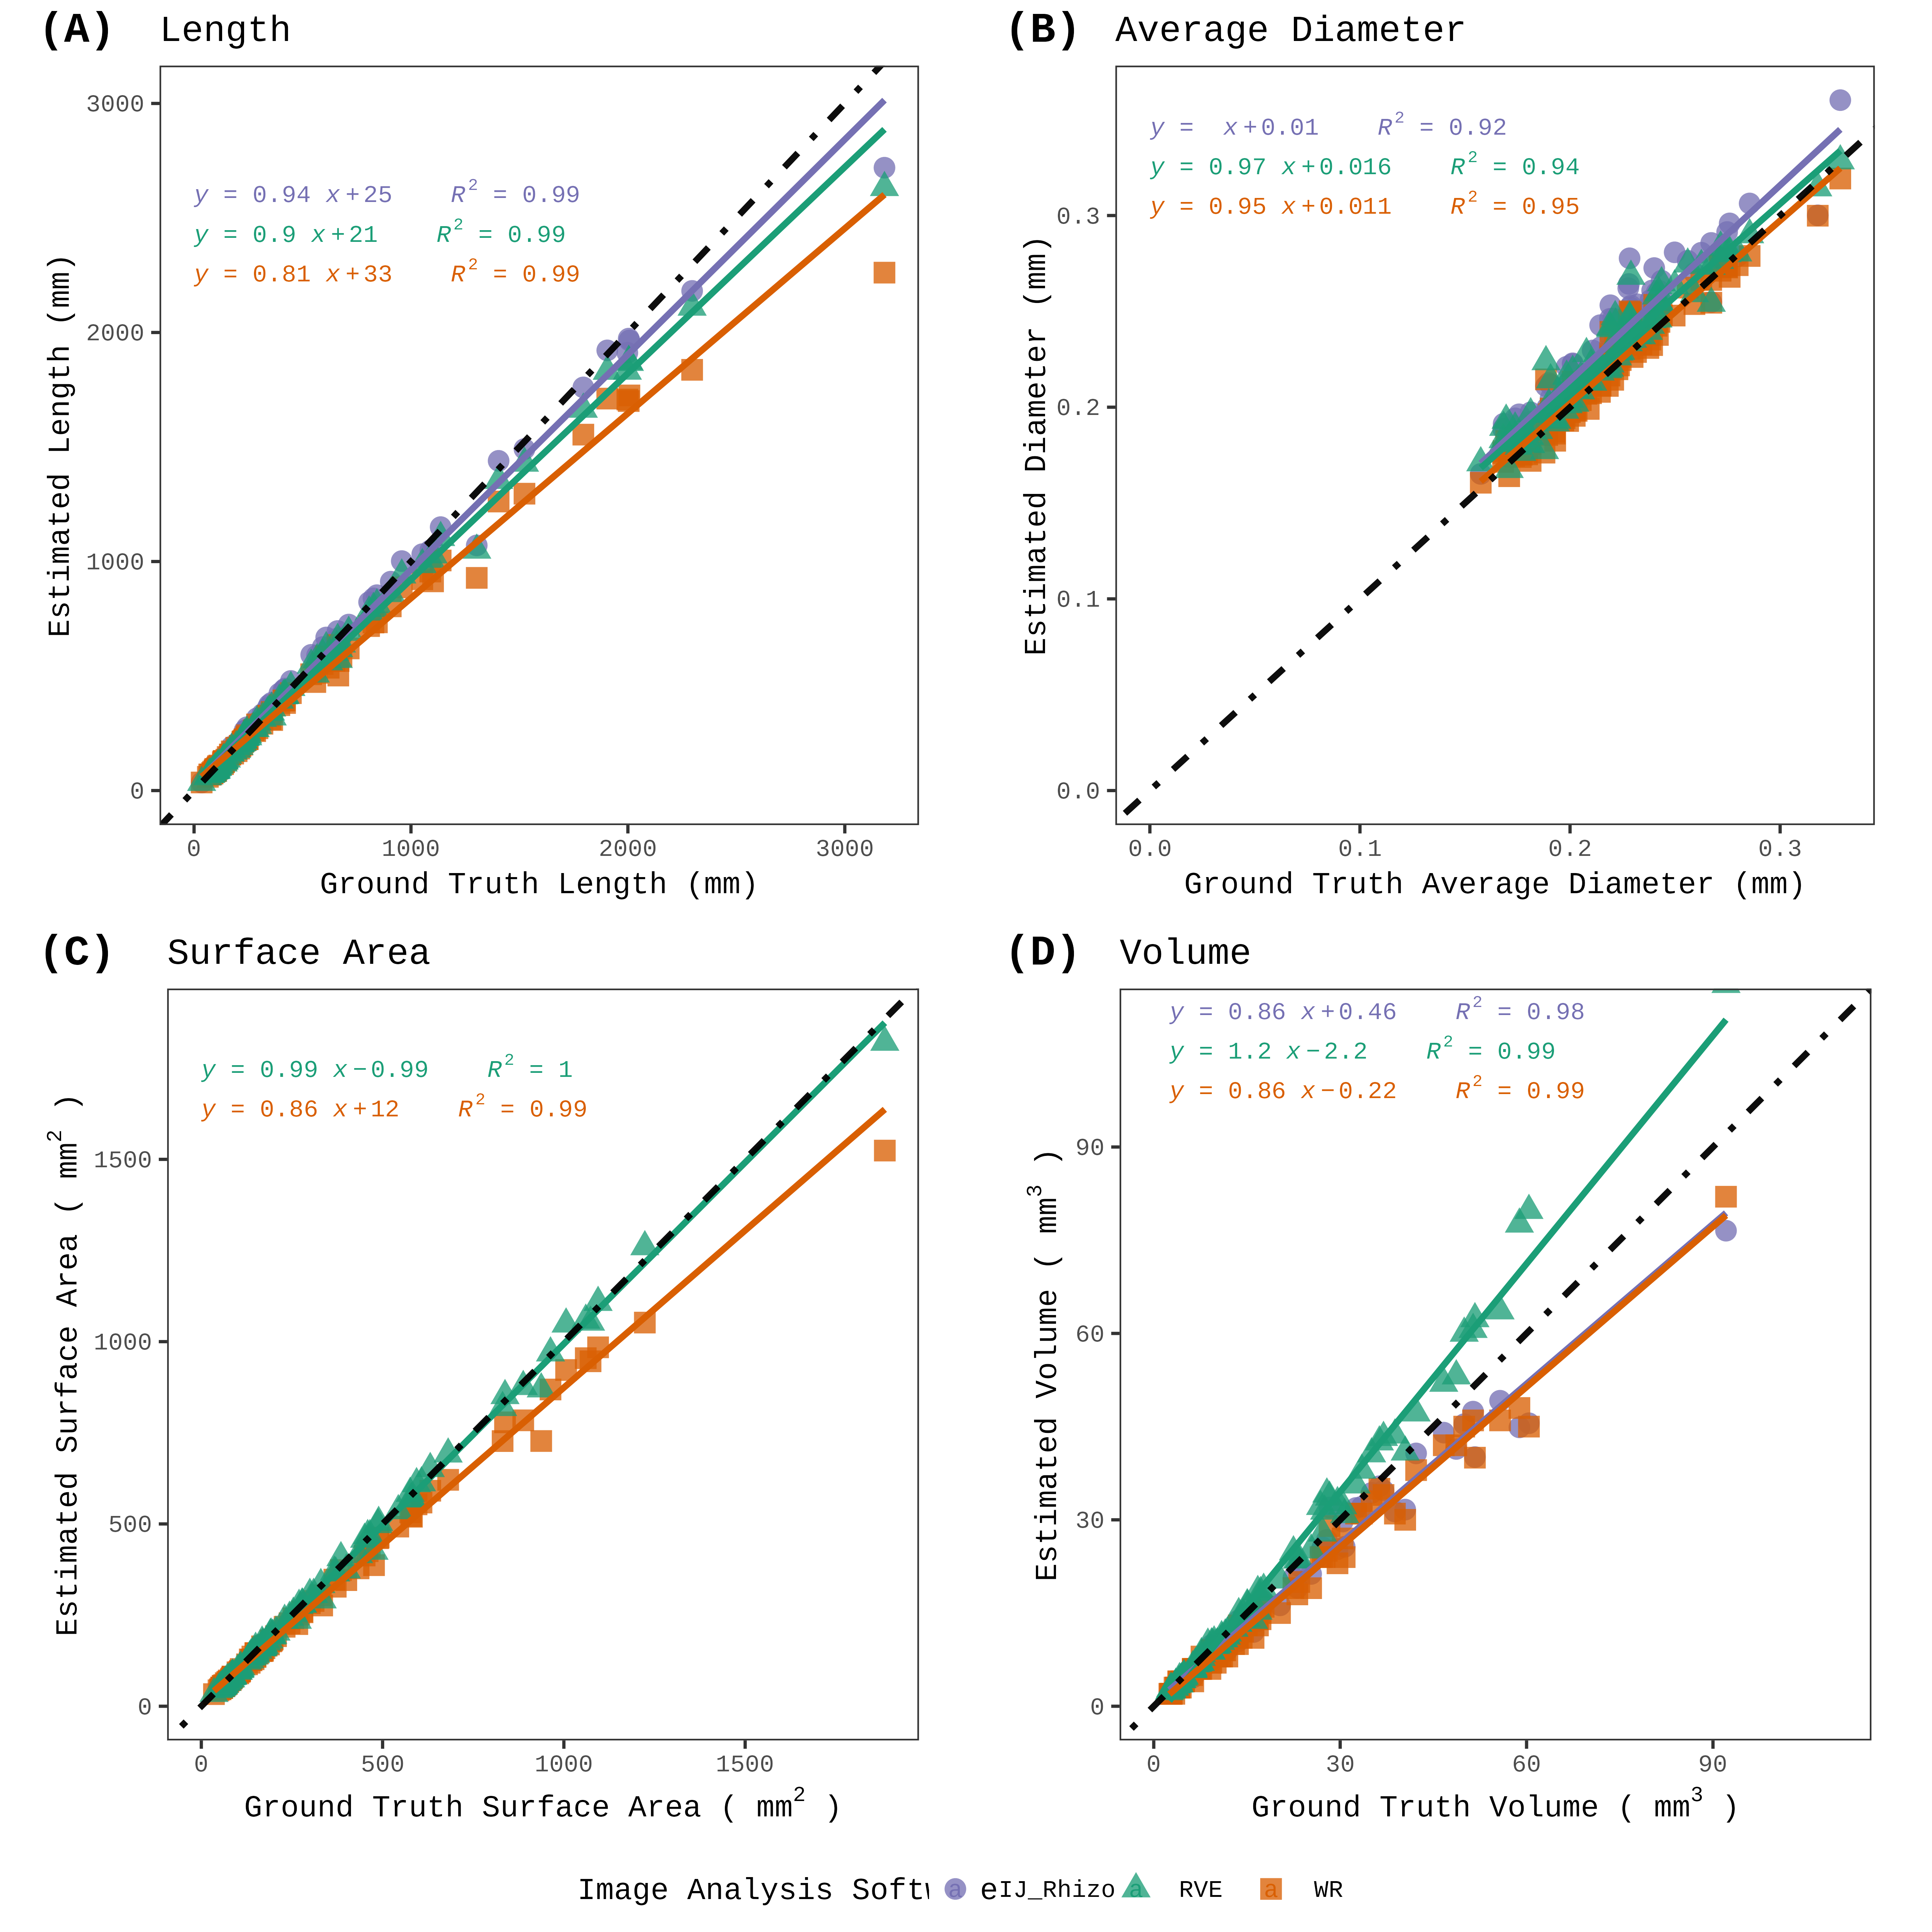

cuWiresWrRve.png


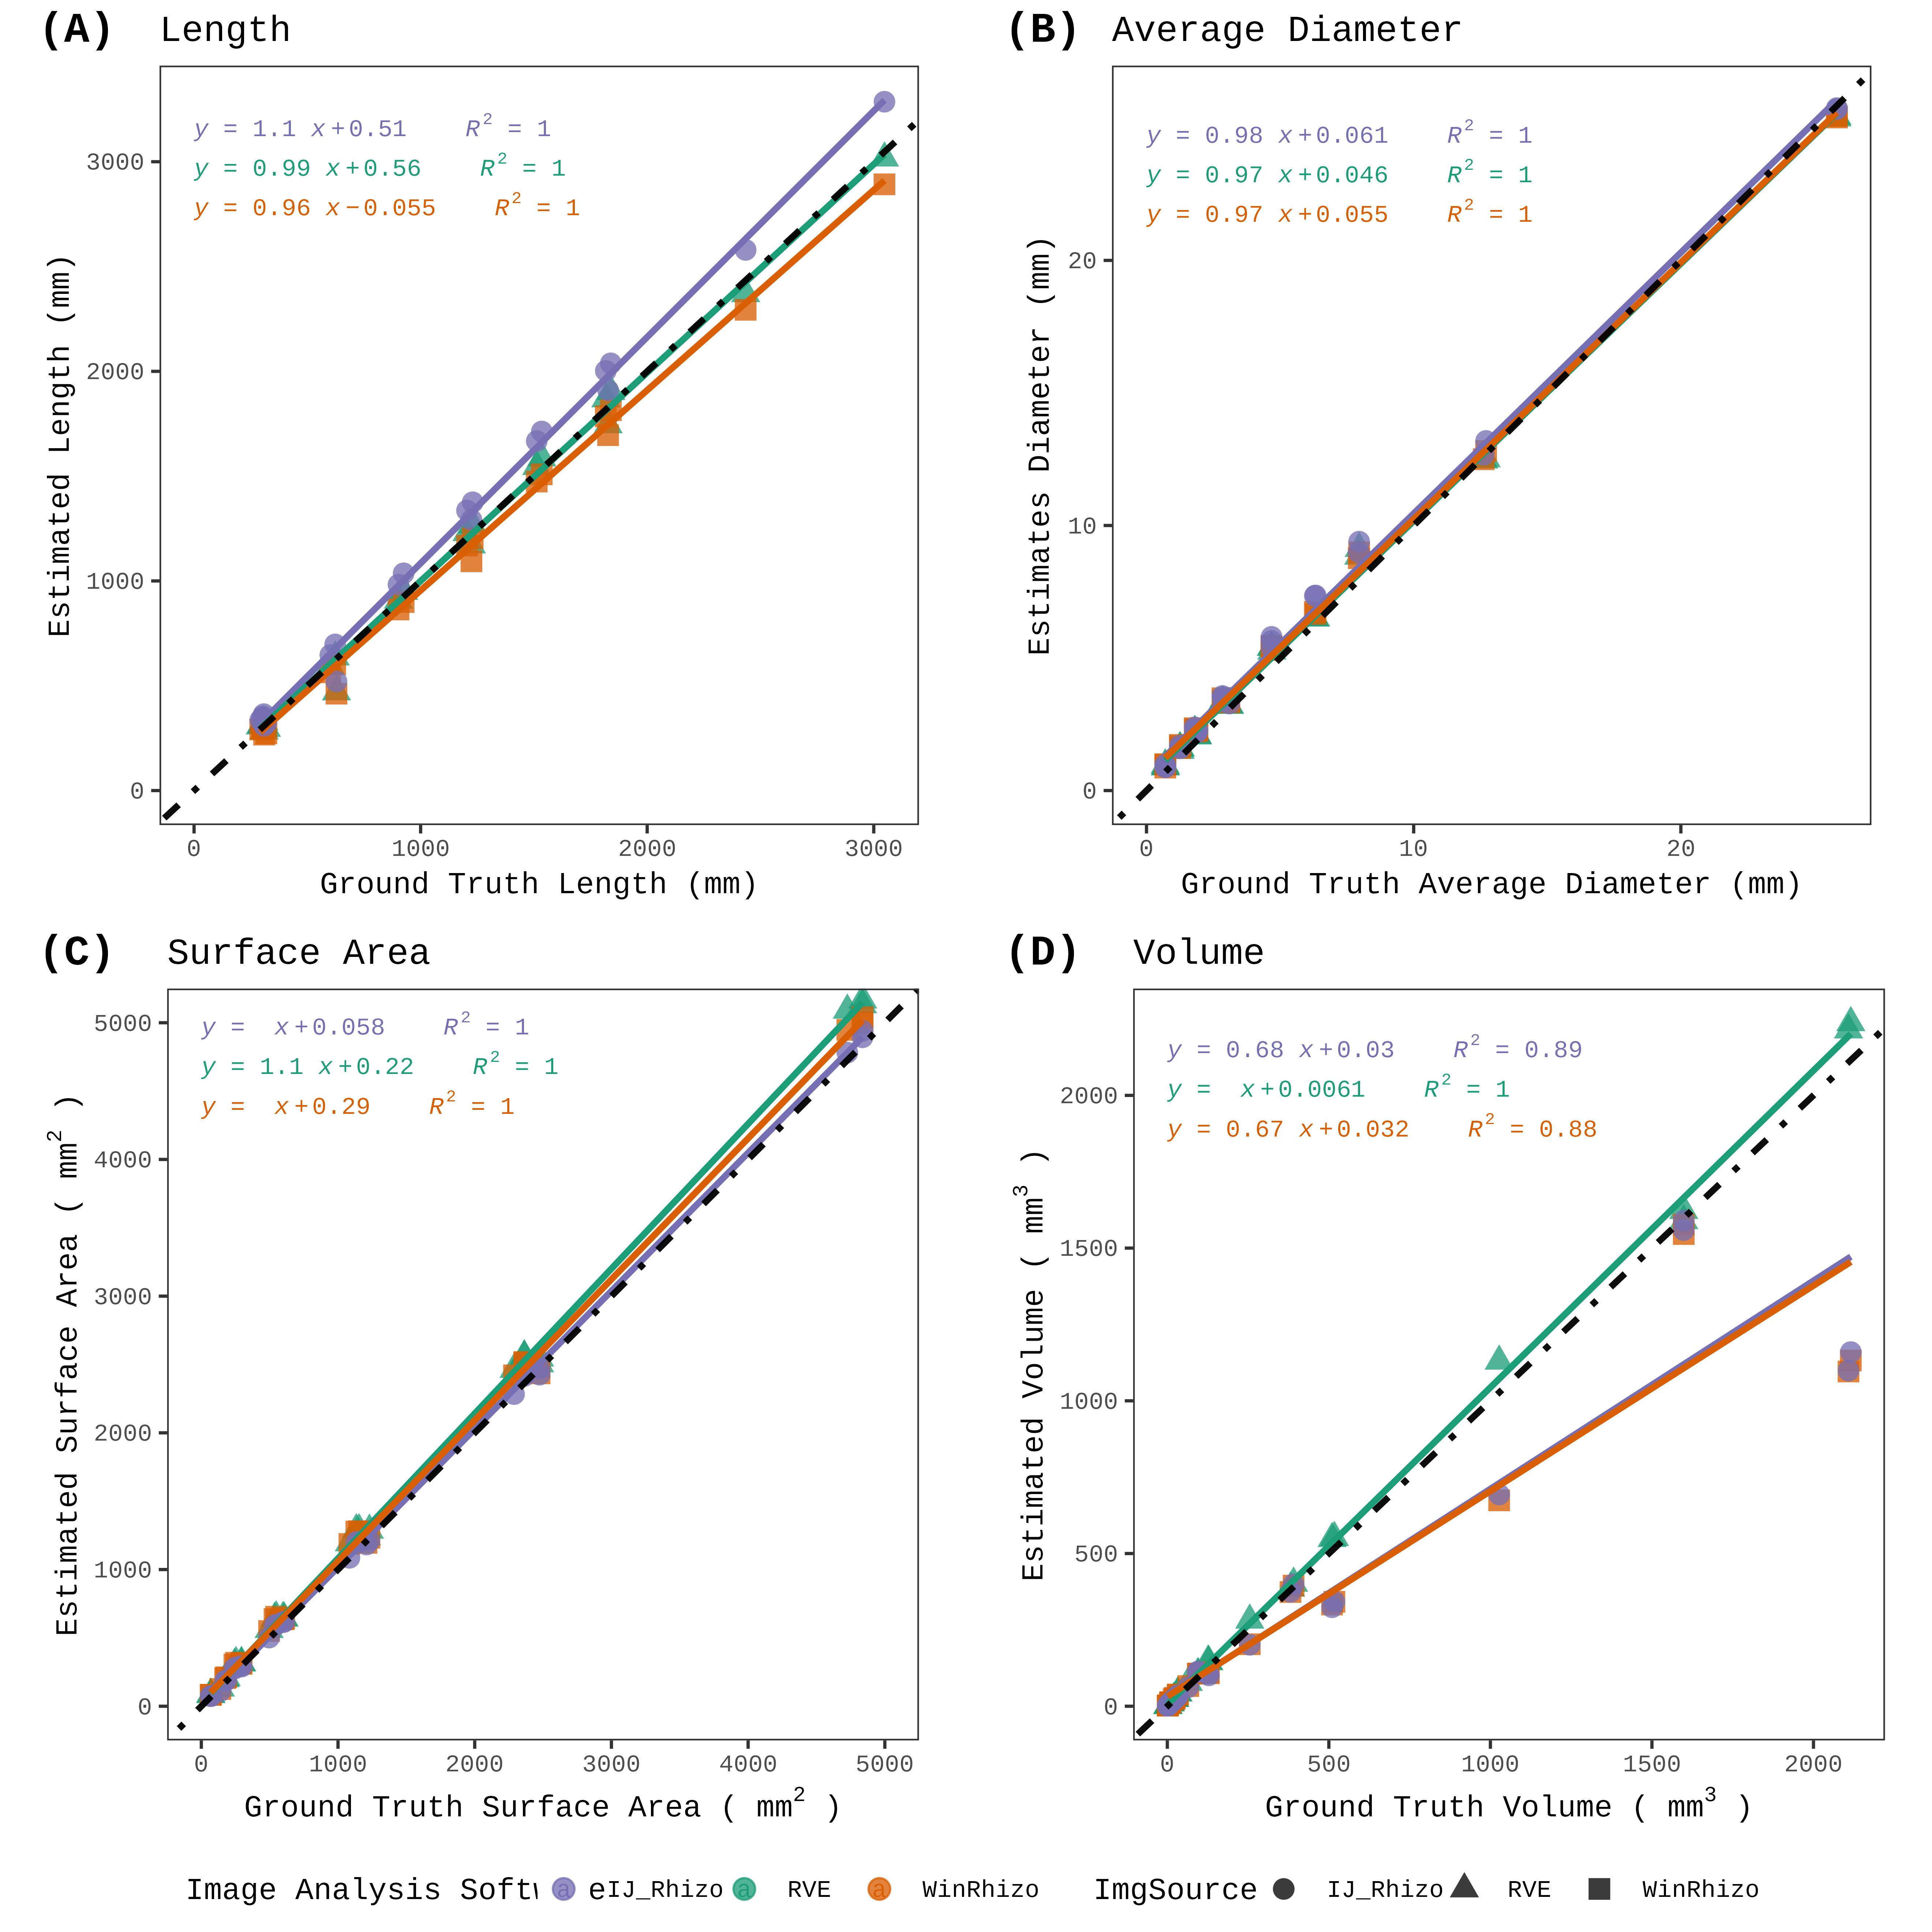

multipleSpecies_WinR_RVE.png


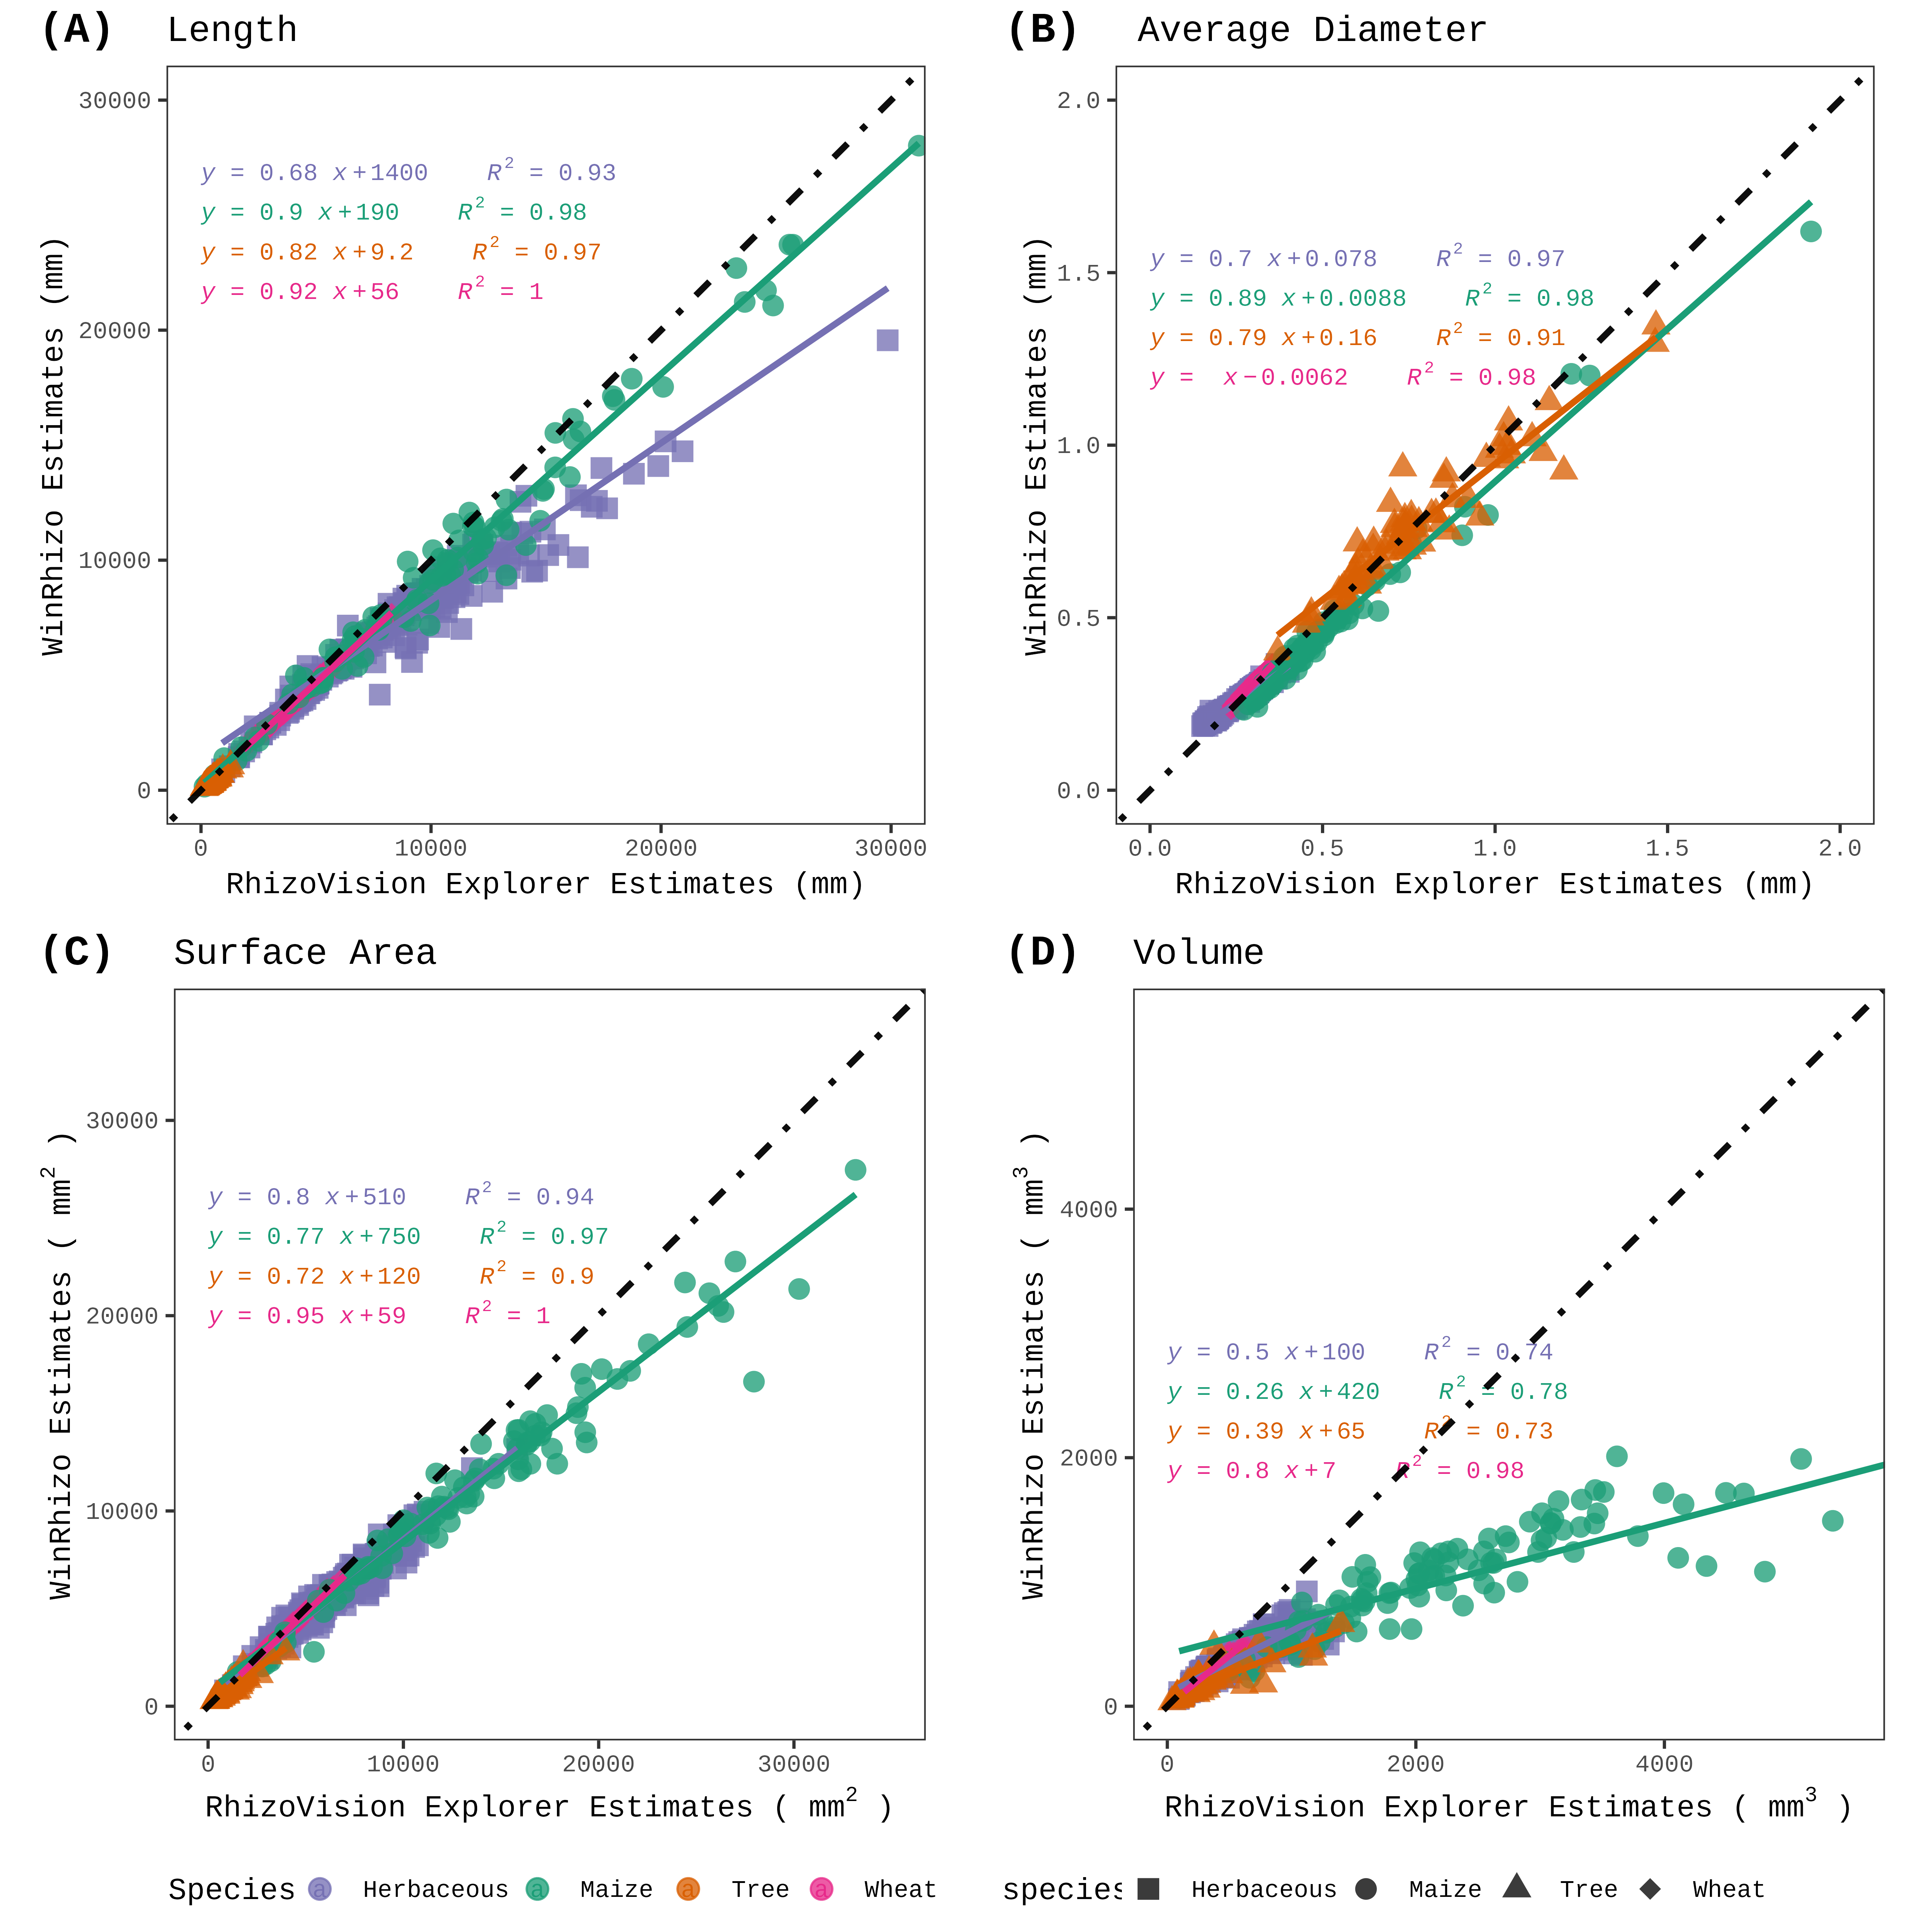

In [ ]:
from IPython.display import Image, display
import os

figdir = "/content/rve/outputFigures"
pngs = sorted(f for f in os.listdir(figdir) if f.lower().endswith(".png"))
assert pngs, "no PNG figures produced by the script"
for f in pngs[:4]:
    print(f)
    display(Image(filename=os.path.join(figdir, f), width=700))

## Limitations / 制限

- This reproduces the paper's **statistical validation** (accuracy metrics, software comparisons and figures). The RVE image-analysis pipeline itself (skeletonization, pruning, trait extraction) is not re-run; that would require the Windows GUI binary (Zenodo 3747697) or building the C++/Qt/OpenCV source (github.com/noble-research-institute/RhizoVisionExplorer @ a299a1a7).
- `Inputs/all_D.Rdata` is absent from the data deposit; it is reconstructed in section 5 from the cited Rose & Lobet (2019) ground-truth record (Zenodo 1159846) using those authors' published aggregation recipe, with checksums and a magnitude cross-check against RVE's own output. Regenerated simulated-root metrics therefore depend on this documented reconstruction.
- Four minimal patches to the released script are printed in section 4 (headless working directory, one input path prefix, one column-drop line that breaks a released `rbind`, and a vectorized `if` condition); the copper-wire metrics and figures regenerate cleanly with them.
- WinRhizo and IJ_Rhizo comparison values are the authors' published measurements bundled in the deposit; those proprietary tools are not re-run here.
- 制限: 本ノートブックは統計検証のみを再現します。画像解析パイプライン本体や WinRhizo/IJ_Rhizo 自体の再実行は含みません。`all_D.Rdata` は文献のレシピに基づく再構成です。

**Provenance:** paper doi:10.1093/aobpla/plab056; data+code doi:10.5281/zenodo.4677553 (md5-verified); simulated-root ground truth doi:10.5281/zenodo.1159846 (md5-verified); author code github.com/noble-research-institute/RhizoVisionExplorer @ a299a1a7 (not executed here).